Found 3829 files belonging to 6 classes.
Using 3064 files for training.
Found 3829 files belonging to 6 classes.
Using 765 files for validation.

Classes Found
0 : Bacterial Leaf Blight
1 : Brown Spot
2 : Healthy Rice Leaf
3 : Leaf Blast
4 : Leaf scald
5 : Sheath Blight



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10


c:\Users\LENOVO\Desktop\vks\ALL PROJECTS\crop-disease-detection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - accuracy: 0.3123 - loss: 1.7996
Epoch 1: val_accuracy improved from None to 0.47059, saving model to models\mobilenet.keras

Epoch 1: finished saving model to models\mobilenet.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 129s 941ms/step - accuracy: 0.3123 - loss: 1.7996 - val_accuracy: 0.4706 - val_loss: 1.3093 - learning_rate: 1.0000e-04
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.4765 - loss: 1.3579
Epoch 2: val_accuracy improved from 0.47059 to 0.57386, saving model to models\mobilenet.keras

Epoch 2: finished saving model to models\mobilenet.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 53s 546ms/step - accuracy: 0.4765 - loss: 1.3579 - val_accuracy: 0.5739 - val_loss: 1.1278 - learning_rate: 1.0000e-04
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 840ms/step - accuracy: 0.5277 - loss: 1.2165
Epoch 3: val_accuracy improved from 0.57386 to 0.59739, saving model to models\mobilenet.keras

Epoch 3: finished saving model to models\mobilenet.keras
96/9

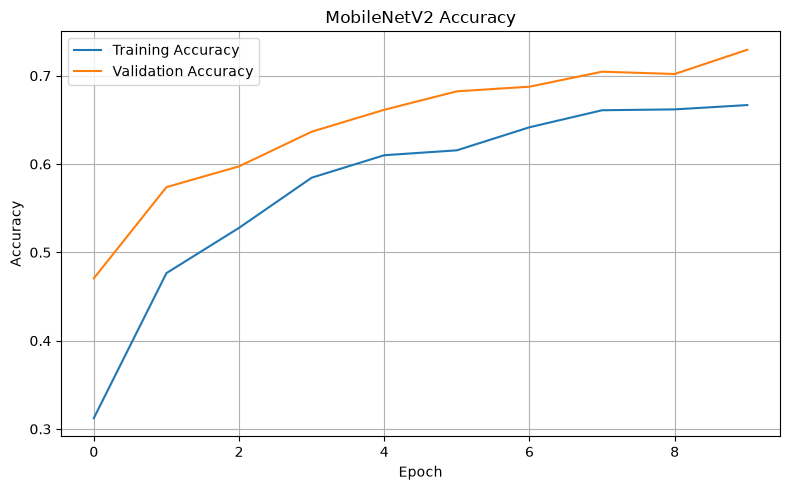

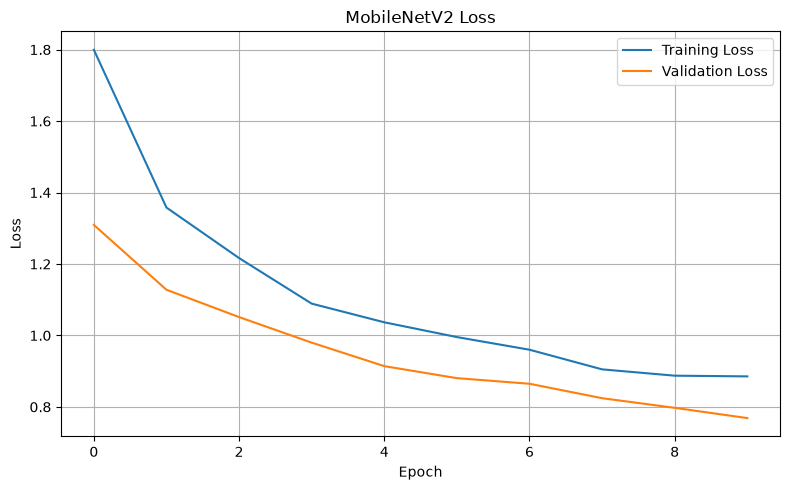


Graphs saved successfully.
Model saved successfully.

Training Complete.


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

import matplotlib.pyplot as plt

# ======================================================
# CONFIGURATION
# ======================================================

DATASET_PATH = "../DATASETS/Rice_Leaf_AUG"
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
SEED = 123

MODEL_DIR = "models"
PLOT_DIR = "plots"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# ======================================================
# LOAD DATASET
# ======================================================

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names

print("\n===================================")
print("Classes Found")
print("===================================")

for i, cls in enumerate(class_names):
    print(f"{i} : {cls}")

print("===================================\n")

# ======================================================
# PERFORMANCE OPTIMIZATION
# ======================================================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)

# ======================================================
# DATA AUGMENTATION
# ======================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
])

# ======================================================
# LOAD MOBILENETV2
# ======================================================

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze all layers
base_model.trainable = False

# ======================================================
# BUILD MODEL
# ======================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.30)(x)

x = layers.Dense(256, activation="relu")(x)

x = layers.Dropout(0.30)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = models.Model(inputs, outputs)

# ======================================================
# COMPILE
# ======================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ======================================================
# CALLBACKS
# ======================================================

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, "mobilenet.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        verbose=1
    )
]

# ======================================================
# TRAIN
# ======================================================

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

# ======================================================
# FINAL VALIDATION
# ======================================================

loss, accuracy = model.evaluate(validation_dataset)

print("\n===================================")
print(f"Validation Loss     : {loss:.4f}")
print(f"Validation Accuracy : {accuracy*100:.2f}%")
print("===================================")

# ======================================================
# ACCURACY GRAPH
# ======================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("MobileNetV2 Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(PLOT_DIR, "accuracy.png"),
    dpi=300
)

plt.show()  # Display inline in notebook

# ======================================================
# LOSS GRAPH
# ======================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("MobileNetV2 Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.tight_layout()
 
plt.savefig(
    os.path.join(PLOT_DIR, "loss.png"),
    dpi=300
)

plt.show()  # Display inline in notebook

print("\nGraphs saved successfully.")
print("Model saved successfully.")
print("\nTraining Complete.")

Generating predictions...


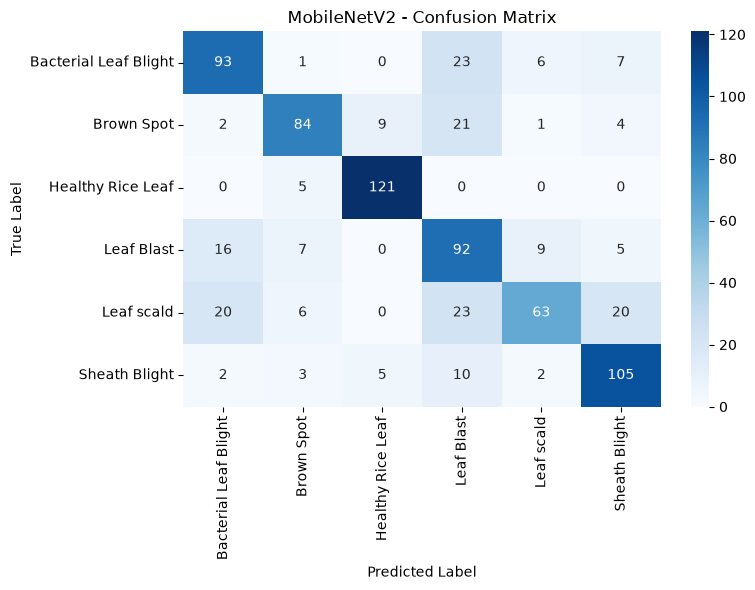


Classification Report
                       precision    recall  f1-score   support

Bacterial Leaf Blight       0.70      0.72      0.71       130
           Brown Spot       0.79      0.69      0.74       121
    Healthy Rice Leaf       0.90      0.96      0.93       126
           Leaf Blast       0.54      0.71      0.62       129
           Leaf scald       0.78      0.48      0.59       132
        Sheath Blight       0.74      0.83      0.78       127

             accuracy                           0.73       765
            macro avg       0.74      0.73      0.73       765
         weighted avg       0.74      0.73      0.73       765


Confusion matrix saved to 'plots/confusion_matrix.png'
Classification report saved to 'plots\mobilenet_metrics_report.txt'


In [2]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ======================================================
# GENERATE PREDICTIONS
# ======================================================

# Extract true labels and compute predictions for validation dataset
y_true = []
y_pred = []

print("Generating predictions...")
for images, labels in validation_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ======================================================
# CONFUSION MATRIX
# ======================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=class_names, 
    yticklabels=class_names
)

plt.title("MobileNetV2 - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

# Save plot
plt.savefig(
    os.path.join(PLOT_DIR, "confusion_matrix.png"), 
    dpi=300
)
plt.show()

# ======================================================
# CLASSIFICATION REPORT
# ======================================================

report = classification_report(y_true, y_pred, target_names=class_names)

print("\n===================================")
print("Classification Report")
print("===================================")
print(report)

# Save report to text file
report_path = os.path.join(PLOT_DIR, "mobilenet_metrics_report.txt")
with open(report_path, "w") as f:
    f.write(report)

print(f"\nConfusion matrix saved to '{PLOT_DIR}/confusion_matrix.png'")
print(f"Classification report saved to '{report_path}'")

Loading model from: models\mobilenet.keras
Found 3829 files belonging to 6 classes.
Using 765 files for validation.

Extracting validation images and labels...
Running model predictions on full validation set...
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 273ms/step

MODEL EVALUATION SUMMARY
Accuracy        : 72.94%
Macro Precision : 0.7425
Macro Recall    : 0.7312
Macro F1 Score  : 0.7278

CLASSIFICATION REPORT
                       precision    recall  f1-score   support

Bacterial Leaf Blight     0.6992    0.7154    0.7072       130
           Brown Spot     0.7925    0.6942    0.7401       121
    Healthy Rice Leaf     0.8963    0.9603    0.9272       126
           Leaf Blast     0.5444    0.7132    0.6174       129
           Leaf scald     0.7778    0.4773    0.5915       132
        Sheath Blight     0.7447    0.8268    0.7836       127

             accuracy                         0.7294       765
            macro avg     0.7425    0.7312    0.7278       765
         weighted avg     0.7

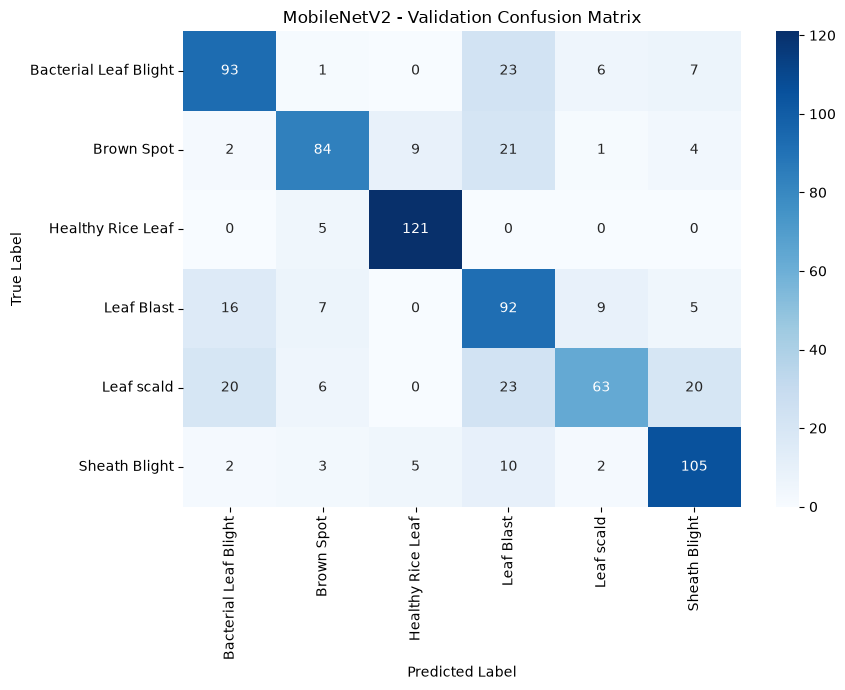

In [6]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing import image
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_recall_fscore_support
)

# ---------------------------------
# CONFIGURATION
# ---------------------------------

MODEL_PATH = os.path.join("models", "mobilenet.keras")
DATASET_PATH = "../DATASETS/Rice_Leaf_AUG"

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 123

# ---------------------------------
# LOAD MODEL & VALIDATION DATASET
# ---------------------------------

print(f"Loading model from: {MODEL_PATH}")
model = tf.keras.models.load_model(MODEL_PATH)

# FIXED: shuffle=True + seed=123 matches training split exactly across ALL 6 classes
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True 
)

class_names = val_ds.class_names
class_indices = list(range(len(class_names)))

# Unpack all images and labels from the validation generator
print("\nExtracting validation images and labels...")
y_true = []
all_images = []

for imgs, labels in val_ds:
    all_images.append(imgs)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
all_images = np.concatenate(all_images, axis=0)

# ==========================================================
# EVALUATE
# ==========================================================

print("Running model predictions on full validation set...")
predictions = model.predict(all_images, verbose=1)
y_pred = np.argmax(predictions, axis=1)

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, 
    y_pred, 
    labels=class_indices,
    average="macro",
    zero_division=0
)

print("\n" + "=" * 65)
print("MODEL EVALUATION SUMMARY")
print("=" * 65)
print(f"Accuracy        : {accuracy*100:.2f}%")
print(f"Macro Precision : {precision:.4f}")
print(f"Macro Recall    : {recall:.4f}")
print(f"Macro F1 Score  : {f1:.4f}")

print("\n" + "=" * 65)
print("CLASSIFICATION REPORT")
print("=" * 65)
print(
    classification_report(
        y_true, 
        y_pred, 
        labels=class_indices,
        target_names=class_names, 
        digits=4,
        zero_division=0
    )
)

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=class_indices)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MobileNetV2 - Validation Confusion Matrix")
plt.tight_layout()

os.makedirs("plots", exist_ok=True)
plt.savefig("plots/eval_confusion_matrix.png", dpi=300)
plt.show()